# Data Science bootcamp
В данном ноутбуке представлено решение контеста на отбор [`Data Science bootcamp`](https://start.avito.ru/datascience-bootcamp) по направлению [`classic ml`](https://stepik.org/lesson/2589118/step/1).

## Участник
**Бондаренко Федор Алексеевич** (fedobondarenko@gmail.com, [GitHub](https://github.com/FedorProgrammer), [stepik](https://stepik.org/users/189216442/profile))

# Оглавление:
- [Подготовка окружения](#env)
    - [Зависимостей](#deps)
    - [Конфигурация](#config)
        - [Импорты](#imports)
        - [Параметры обучения](#params)
    - [Воспроизводимость](#repro)
- [Обработка данных](#data)
    - [Загрузка данных](#load)
    - [Примеры данных](#examples)
    - [Сплит ивентов](#split)
        - [Проверка отброшенных ивентов](#leakage-check)
    - [EDA](#eda)
        - [Типы данных](#types)
        - [Пропуски в данных](#missing)
            - [Координаты курсора](#pointers)
            - [Поисковый запрос](#search)
            - [Данные item'а](#item-data)
                - [Совместно с `event_name`](#with-event-name)
        - [Распределение баланса классов](#balance-dist)
            - [На train выборке](#train-balance)
            - [На events выборке](#events-balance)
                - [Без нормировки](#no-norm)
        - [Временное распределение](#time-dist)
        - [Распределение платформы](#platform-dist)
        - [Распределение событий](#events-dist)
        - [Интенсивность событий](#intensity)
- [Feature engineering](#feature-engineering)
- [Валидация](#validation)
- [Подбор гиперпараметров](#tuning)
- [Бейзлайн](#baseline)
- [Обучение](#training)
    - [Основанное на поведенческих признаках](#training-fe)
    - [Дополненное текстовыми признаками](#training-text)
    - [Анализ признаков](#features-analysis)
- [Сабмит](#submission)
- [Вывод](#conclusion)

# Подготовка окружения <a id="env"></a>

### Зависимости <a id="deps"></a>
Устанавливаем необходимые файлы:
1. датасет (трейн, тест, события);
2. модуль `metric.py`;
3. пример решения.

> В дальнейшем, данные для обучения будут браться из директории `data/`.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

def download_challenge_data() -> None:
    '''Устанавливает данные по ссылке, что была опубликована на странице контеста
    '''
    data_path = Path("data")
    if not data_path.is_dir():
        zip_path = Path("challenge_data.zip")
        url = "https://stepik.org/media/attachments/lesson/2589118/bot_detection_challenge.zip"
        urllib.request.urlretrieve(url, zip_path)
        
        with zipfile.ZipFile(zip_path) as challenge_zip:
            challenge_zip.extractall(path=".")
        zip_path.unlink()
        print('Данные успешно установлены')
    else:
        print("Данные уже установлены")

download_challenge_data()

Данные уже установлены


## Конфигурация <a id="config"></a>

### Импорты <a id="imports"></a>
Подключаем все необходимые библиотеки для: 
- обработки данных;
- обучения модели;
- оценки ее качества;
- визуализации.

In [2]:
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

import catboost as cb

import metric

%matplotlib inline

### Параметры обучения <a id="params"></a>
Задаем основные параметры обучения

In [3]:
SEED = 42

N_SPLITS = 3
ITERATIONS = 1500

## Воспроизводимость <a id="repro"></a>
Делаем обучение воспроизводимым -- фиксируем сиды.

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
print(f"Глобальный сид установлен; его значение == {SEED}")

Глобальный сид установлен; его значение == 42


# Обработка данных <a id="data"></a>

## Загрузка данных <a id="load"></a>

In [5]:
train = pd.read_csv("data/train.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv("data/test.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv("data/events.csv.gz", parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)

(11091, 5) (4909, 4) (328905, 14)


## Примеры данных <a id="examples"></a>

In [6]:
train.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
1891,ck_8df0e1700243310f,2026-04-07 07:17:48,2026-04-08,2026-04-09,0
9165,ck_4d70e8e03b078415,2026-02-24 18:14:14,2026-04-17,2026-04-18,0
3902,ck_eebaaa38fb01fa72,2026-01-19 04:48:21,2026-04-10,2026-04-11,0
10213,ck_1388b91f875a4fe2,2025-10-25 21:40:01,2026-04-18,2026-04-19,0
883,ck_d6cd2e957f758107,2026-03-08 14:25:06,2026-04-07,2026-04-08,0


In [7]:
test.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
861,ck_962e65ab33b5c311,2026-04-18 17:27:47,2026-04-21,2026-04-22
2974,ck_501dcf1ead036d2b,2026-03-08 23:07:09,2026-04-24,2026-04-25
3963,ck_68250033717cd59e,2026-03-01 09:48:41,2026-04-25,2026-04-26
1774,ck_e914974cee1bccb1,2026-04-20 05:01:29,2026-04-22,2026-04-23
4360,ck_64eefec062592c43,2026-02-15 04:53:36,2026-04-26,2026-04-27


In [8]:
events.sample(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
72257,ck_d026b2dc7227d214,2026-04-07 17:27:59,210,photo_swipe,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1034301.0,zhivotnye,moskva,pro,NaN,NaN,NaN,NaN
150048,ck_e1a21ba313896b9b,2026-04-08 01:47:31,100,search_results_view,Web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,mebel,novosibirsk,NaN,кровать 160х200,1.0,NaN,NaN
294032,ck_16c9b12c2561cab9,2026-04-17 23:53:28,301,contact_chat_open,Android,Mozilla/5.0 (Linux; Android 12; SM-A515F) Appl...,1021852.0,telefony,cheboksary,pro,NaN,NaN,NaN,NaN
157557,ck_9e84edadcce8c071,2026-04-08 11:53:26,400,favorite_add,ANDROID,Mozilla/5.0 (Linux; Android 14; Pixel 6) Apple...,1051814.0,bytovaya_tehnika,moskva,private,NaN,NaN,NaN,NaN
279786,ck_f409ff994a210601,2026-04-25 17:37:27,200,item_view,Android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1034262.0,hobbi,ekaterinburg,private,NaN,NaN,NaN,NaN


### Нормализация `events[platform]` <a id='normalizing'></a>
Множество платформ-синонимов может вносить дополнительный шум -- объединим похожие.

In [9]:
events['platform'].value_counts()

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

In [10]:
events['platform'] = events['platform'].replace(['WEB', 'Web', 'web'], 'WEB')
events['platform'] = events['platform'].replace(['ANDROID', 'Android', 'android'], 'ANDROID')
events['platform'] = events['platform'].replace(['iphone', 'IOS', 'iOS', 'ios'], 'IOS')

events['platform'].value_counts()

platform
WEB        138792
ANDROID    126875
desktop     46866
IOS         16372
Name: count, dtype: int64

## Сплит ивентов <a id="split"></a>

In [11]:
def split_events(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    '''Функция для добавления мета-данных куки
    '''
    meta_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']
    ev = events.merge(meta[meta_columns], on='cookie_id', how='right')
    
    mask = (ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts'])
    return ev[mask]

events_tr = split_events(events, train)
events_tr_labeled = events_tr.merge(train[['cookie_id', 'target']], on='cookie_id')

events_te = split_events(events, test)

events.shape, events_tr.shape, events_te.shape

((328905, 14), (198436, 16), (89690, 16))

**Наблюдение:** из датафрейма `events` пропало ~40_000 объектов. Скорее всего это дело временной маски.

### Проверка отброшенных ивентов <a id="leakage-check"></a>
Если отброшенные события произошли после окна события, то при их использовании (например, для заполнения пропусков) возможна утечка.  
Проверим это:

In [12]:
def get_dropped_events(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    meta_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']
    ev = events.merge(meta[meta_columns], on='cookie_id', how='right')

    mask = ~((ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts']))
    return ev[mask]

dropped_tr = get_dropped_events(events, train)
dropped_te = get_dropped_events(events, test)

dropped_tr.shape, dropped_te.shape

((40779, 16), (0, 16))

In [13]:
before = dropped_tr[dropped_tr['event_ts'] < dropped_tr['window_start_ts']]
after = dropped_tr[dropped_tr['event_ts'] >= dropped_tr['window_end_ts']]

print(f"Отброшенные до окна: {len(before)}, отброшенные после окна: {len(after)}")

Отброшенные до окна: 0, отброшенные после окна: 40779


**Наблюдение:** все отброшенные ивенты произошли после окна -- их использование при агрегации может привести к утечке данных.

## EDA <a id="eda"></a>

### Типы данных <a id="types"></a>

In [14]:
train.dtypes

cookie_id                       str
cookie_created_at    datetime64[us]
window_start_ts      datetime64[us]
window_end_ts        datetime64[us]
target                        int64
dtype: object

In [15]:
events.dtypes

cookie_id                   str
event_ts         datetime64[us]
eid                       int64
event_name                  str
platform                    str
user_agent                  str
item_id                 float64
item_category               str
item_location               str
seller_type                 str
search_query                str
search_page             float64
pointer_x               float64
pointer_y               float64
dtype: object

### Пропуски в данных <a id="missing"></a>

In [16]:
train.isna().mean().round(3)

cookie_id            0.0
cookie_created_at    0.0
window_start_ts      0.0
window_end_ts        0.0
target               0.0
dtype: float64

In [17]:
events.isna().mean().round(3)

cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64

In [18]:
events_tr.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.331
item_category      0.079
item_location      0.050
seller_type        0.391
search_query       0.689
search_page        0.689
pointer_x          0.666
pointer_y          0.666
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

In [19]:
events_te.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.333
item_category      0.076
item_location      0.050
seller_type        0.392
search_query       0.687
search_page        0.687
pointer_x          0.672
pointer_y          0.672
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

**Наблюдения:**
- Подозреваю, что большая часть ивентов делается ботами --> отсутствуют координаты курсора?
- Большое количество пропусков курсора может зависить от платформы?
- Пропуски разбились в равных пропорциях (для `events_tr` и `events_te`).

#### Координаты курсора <a id="pointers"></a>

In [20]:
events_tr_labeled.pivot_table(
    index='target', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,pointer_x,pointer_y
target,,
human,0.653,0.653
bot,0.754,0.754


In [21]:
events_tr_labeled.pivot_table(
    index='platform', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,pointer_x,pointer_y
platform,,
ANDROID,1.000,1.000
IOS,1.000,1.000
WEB,0.398,0.398
desktop,0.398,0.398


In [22]:
mask = (events_tr_labeled['platform'].isin(['WEB', 'desktop']))
cursor_cm = events_tr_labeled[mask].pivot_table(
    index='target', columns='platform', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

cursor_cm = cursor_cm['pointer_x'] # pointer_x и pointer_y и так одинаковы
cursor_cm.columns.name = 'pointers'
cursor_cm

pointers,WEB,desktop
target,,
human,0.338,0.338
bot,0.669,0.673


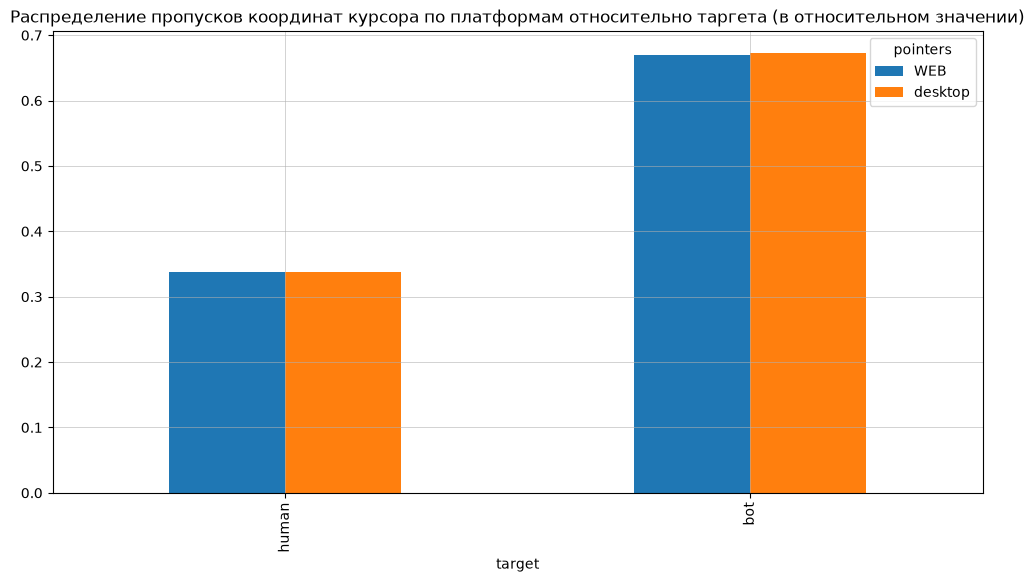

In [23]:
cursor_cm.plot(kind='bar', figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Распределение пропусков координат курсора по платформам относительно таргета (в относительном значении)")
plt.show()

**Наблюдения:**
- Пропуски курсора напрямую зависят от платформы;
- Больше пропусков курсоров у ботов, причем на платформах `WEB` и `desktop`, их **в 2 раза больше** у ботов;
- "Частичных" пропусков координат (пропуск одной из) не наблюдается.

Пропуск координаты курсора -- явный признак.  
Для платформ `ANDROID` и `IOS` следует их заполнить какими-то данными (хотя бы (0, 0)), чтобы модель могла определить реальный пропуск от отсутствия курсора.

#### Поисковый запрос <a id="search"></a>

In [24]:
events_tr_labeled.pivot_table(
    index='target', values=['search_query', 'search_page'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,search_page,search_query
target,,
human,0.695,0.695
bot,0.648,0.648


In [25]:
events_tr_labeled.pivot_table(
    index='event_name', values=['search_query', 'search_page'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,search_page,search_query
event_name,,
contact_chat_open,1.0,1.0
contact_message_sent,1.0,1.0
contact_phone_show,1.0,1.0
favorite_add,1.0,1.0
item_view,1.0,1.0
login,1.0,1.0
photo_swipe,1.0,1.0
search_results_view,0.0,0.0
seller_page_view,1.0,1.0


**Наблюдение:** пропуск у `search_page`/`search_query` строго структурен -- пропуск полностью объясняется типом события.

#### Данные item'а <a id="item-data"></a>

In [26]:
events_tr_labeled.pivot_table(
    index='target', values=['item_id', 'item_category', 'item_location', 'seller_type'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,item_category,item_id,item_location,seller_type
target,,,,
human,0.080,0.326,0.051,0.388
bot,0.069,0.359,0.038,0.416


In [27]:
events_tr_labeled[['seller_type']].value_counts()

seller_type
private        69729
pro            51049
Name: count, dtype: int64

In [28]:
events_tr_labeled['seller_type'].unique()

<StringArray>
['pro', nan, 'private']
Length: 3, dtype: str

**Наблюдения:**
- Дисбаланса почти нет -- оба таргета имеют примерно те же значения пропусков
- Пропуски по `seller_type` могут сигнализировать о "стандартном" типе продавца, а не об отсутствии данных по этому полю как такового (последнее может коррелировать со "спец" ивентами (логин, ...)).

С учетом, что это скорее служебная информация (сложная для агрегатного заполнения), возможно, следует: 
1. отбросить строки с пропусками (для `item_category`, `item_location`)
2. дать `catboost` самому их заполнить

##### Совместно с `event_name` <a id="with-event-name"></a>
Проверим, как часто данные item'а принимают `NaN` по отношению к различным событиям.  
Это может дать ответ на следующие вопросы:
1. Может ли являться `NaN` -- дефолтным значением для `seller_type` (когда у продавца нет `pro`, но профиль не закрыт (`private`))?
2. Что происходит в полях данных айтема при спец ивентах (`login`, ...)?

In [29]:
events_tr_labeled.pivot_table(
    index='event_name', values=['item_id', 'item_category', 'item_location', 'seller_type'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,item_category,item_id,item_location,seller_type
event_name,,,,
contact_chat_open,0.060,0.0,0.032,0.086
contact_message_sent,0.062,0.0,0.031,0.095
contact_phone_show,0.061,0.0,0.029,0.093
favorite_add,0.062,0.0,0.028,0.093
item_view,0.060,0.0,0.030,0.091
login,1.000,1.0,1.000,1.000
photo_swipe,0.058,0.0,0.032,0.089
search_results_view,0.061,1.0,0.031,1.000
seller_page_view,0.059,0.0,0.032,0.091


**Наблюдения:**
- `item_id` по сути всегда заполнен -- его не хватает только на "общих планах"
- `seller_type`==`NaN` действительно может быть дефолтом (при заполненном `item_id` есть объекты с `seller_type` == `NaN`)

Стоит выделить отдельную переменную для более наглядной регистрации ивента `login` -- чтобы модель не путала пропуски при `login` с другими

### Распределение баланса классов <a id="balance-dist"></a>

#### На `train`-выборке <a id="train-balance"></a>

In [30]:
def get_class_balance(df: pd.DataFrame) -> pd.Series:
    '''Обертка над value_counts (с переименованием индекса)
    '''
    return df['target'].value_counts().rename(index={0:'human', 1:'bot'})

In [31]:
train_cls_b = get_class_balance(train)
train_cls_b

target
human    10192
bot        899
Name: count, dtype: int64

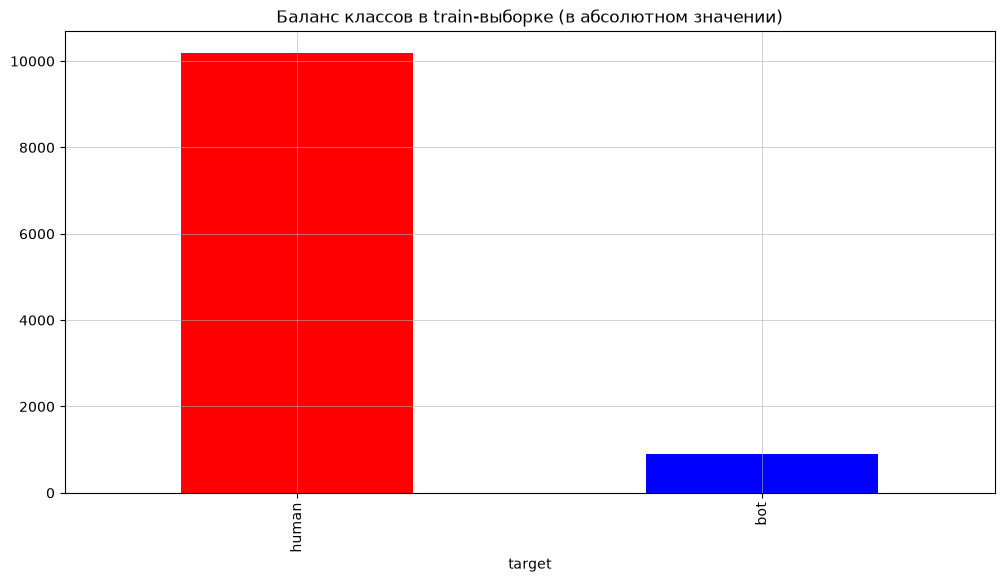

In [32]:
train_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в train-выборке (в абсолютном значении)")
plt.show()

`Train`-выборка имеет четко выраженный дисбаланс в пользу `human`.

#### На `events`-выборке <a id="events-balance"></a>

##### Без нормировки <a id="no-norm"></a>

In [33]:
events_tr_cls_b = get_class_balance(events_tr_labeled)
events_tr_cls_b

target
human    171929
bot       26507
Name: count, dtype: int64

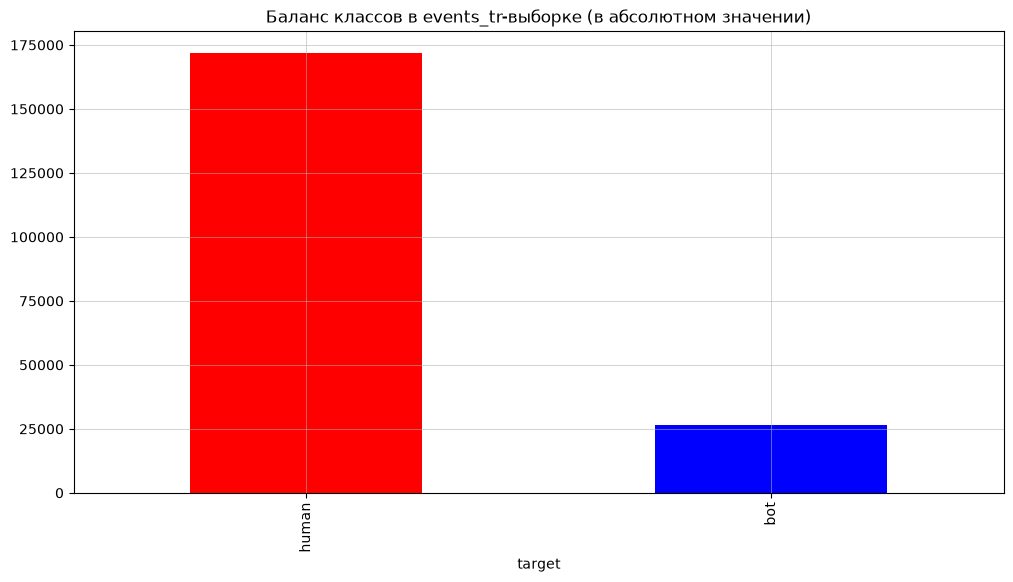

In [34]:
events_tr_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в events_tr-выборке (в абсолютном значении)")
plt.show()

**Наблюдения:**
- Сильный дисбаланс в пользу людей
- Возможно боты и создают ивентов интенсивнее --> попробуем отнормировать

### Временное распределение <a id="time-dist"></a>
Проверка распределения времени:
1. Распределение времени существования кук до их окна (боты могут раньше начать активничать)
2. Распределение создания кук по часам/дням
3. Распределение длительности ивентов

In [35]:
time_tr = train.assign(cookie_age_days=(train['window_start_ts'] - train['cookie_created_at']).dt.days)
time_tr['cookie_created_hr'] = train['cookie_created_at'].dt.hour
time_tr['cookie_created_dow'] = train['cookie_created_at'].dt.day_name()

time_tr.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target,cookie_age_days,cookie_created_hr,cookie_created_dow
5667,ck_b679bf1187328e01,2025-12-16 04:05:17,2026-04-12,2026-04-13,0,116,4,Tuesday
9522,ck_308d37633d0a48ba,2026-04-14 05:44:20,2026-04-17,2026-04-18,0,2,5,Tuesday
5322,ck_ba030a508b6641b7,2025-11-30 02:20:17,2026-04-12,2026-04-13,0,132,2,Sunday
6654,ck_a685818756784fa4,2025-12-24 03:57:43,2026-04-13,2026-04-14,0,109,3,Wednesday
8125,ck_7ad52944a8be8b3d,2026-01-31 19:26:55,2026-04-15,2026-04-16,0,73,19,Saturday


In [36]:
time_tr.groupby('target')['cookie_age_days'].describe().rename(index={0:'human', 1:'bot'})

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
human,10192.0,73.415718,66.959727,0.0,18.0,61.0,110.0,449.0
bot,899.0,48.241379,62.785407,0.0,0.0,18.0,83.0,361.0


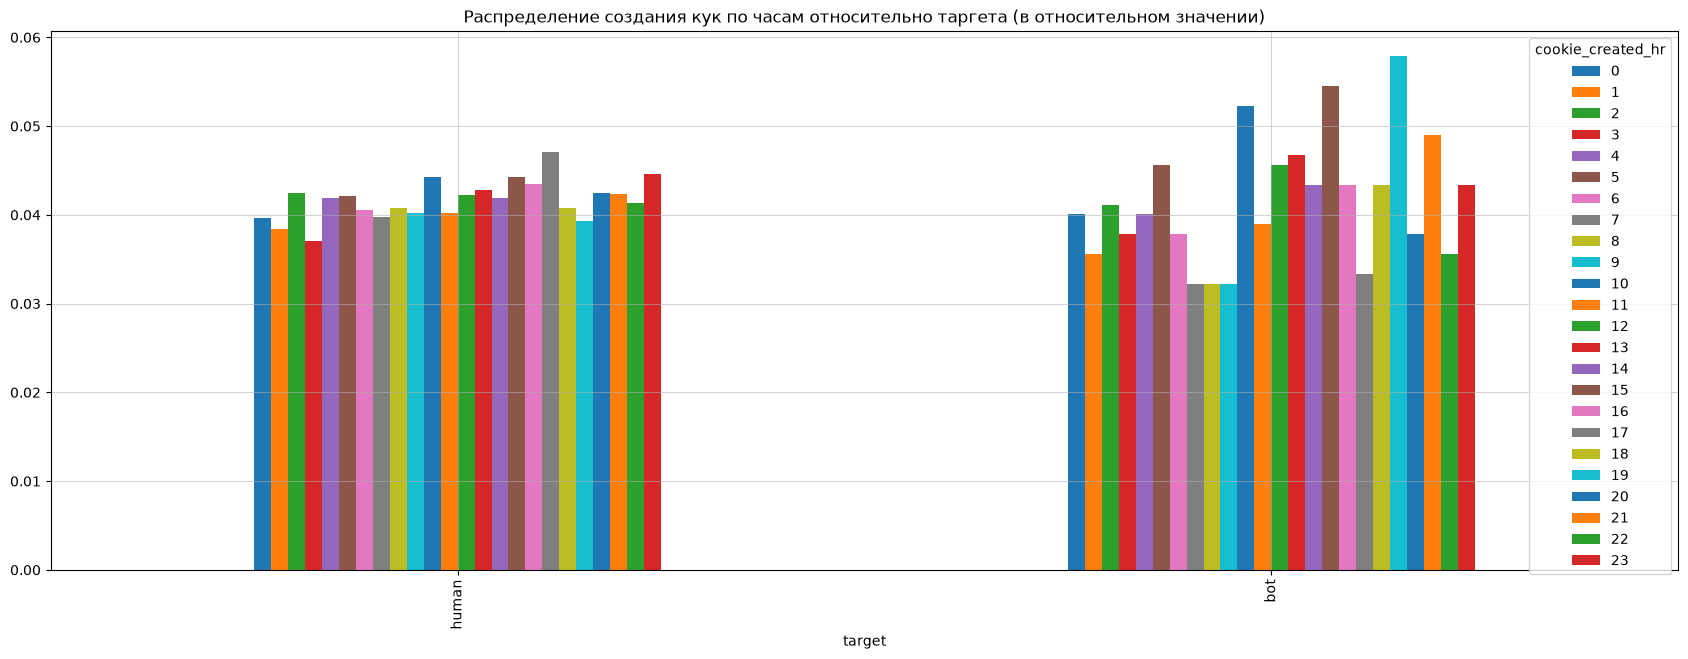

In [37]:
cookie_hr_dist = pd.crosstab(
    index=time_tr['target'], columns=time_tr['cookie_created_hr'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})

cookie_hr_dist.plot(kind='bar', figsize=(21, 7))
plt.grid(True, linewidth=0.4)
plt.title("Распределение создания кук по часам относительно таргета (в относительном значении)")
plt.show()

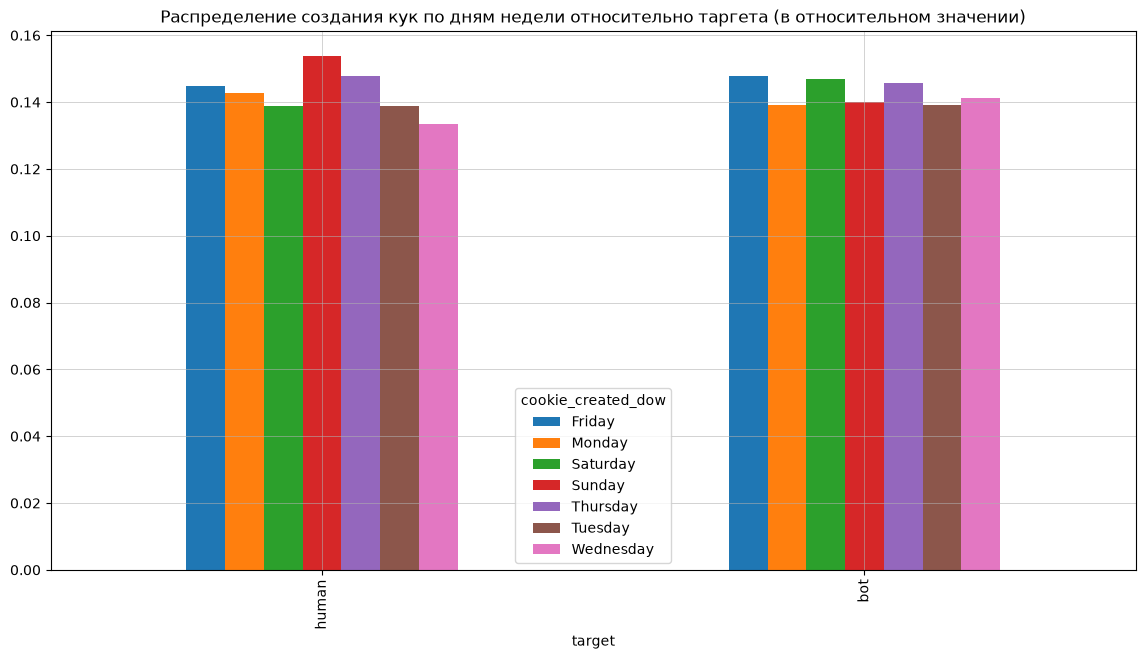

In [38]:
cookie_dow_dist = pd.crosstab(
    index=time_tr['target'], columns=time_tr['cookie_created_dow'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})

cookie_dow_dist.plot(kind='bar', figsize=(14, 7))
plt.grid(True, linewidth=0.4)
plt.title("Распределение создания кук по дням недели относительно таргета (в относительном значении)")
plt.show()

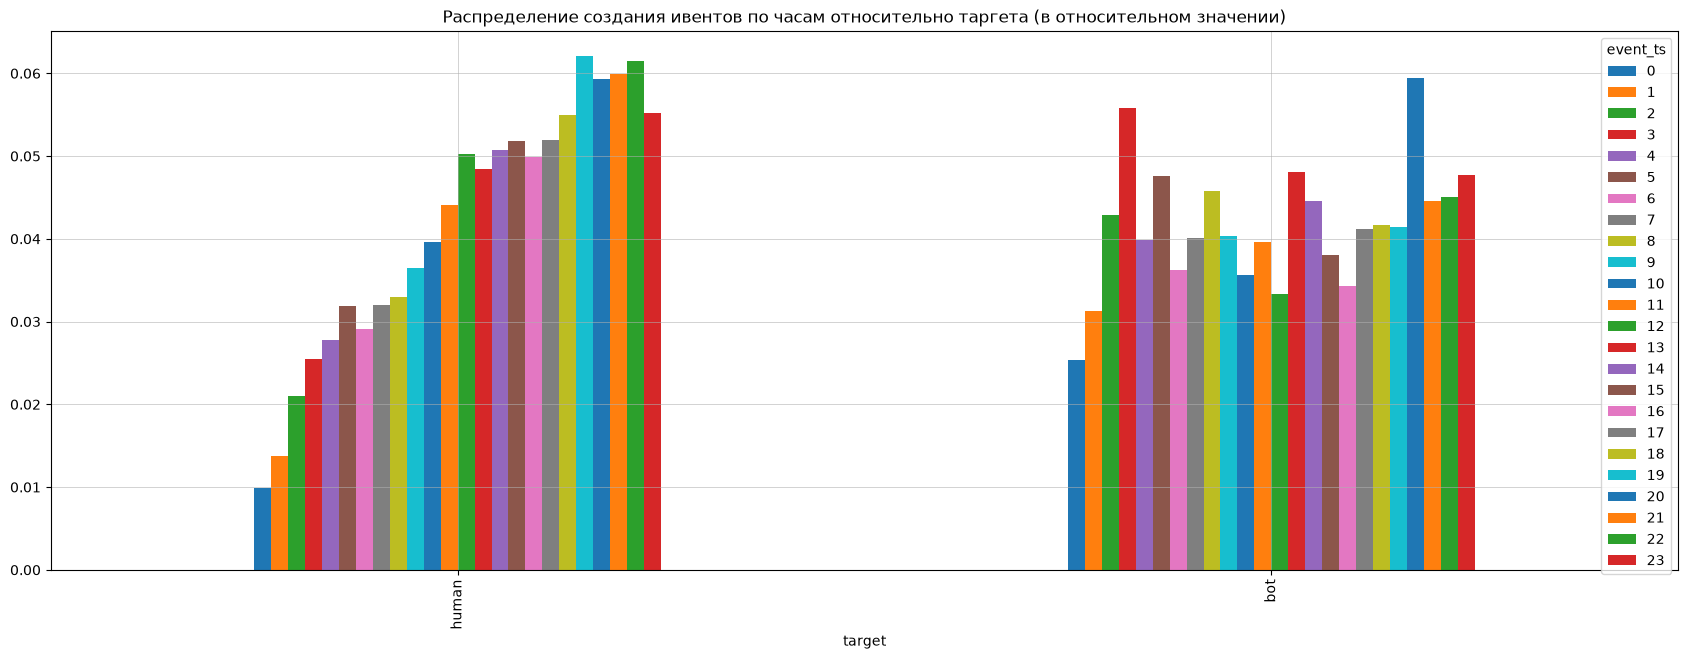

In [39]:
events_hr_dist = pd.crosstab(
    index=events_tr_labeled['target'], columns=events_tr_labeled['event_ts'].dt.hour,
    normalize='index'
).rename(index={0:'human', 1:'bot'})

events_hr_dist.plot(kind='bar', figsize=(21, 7))
plt.grid(True, linewidth=0.4)
plt.title("Распределение создания ивентов по часам относительно таргета (в относительном значении)")
plt.show()

**Наблюдения:**
- В среднем куки человека "живет" до окна дольше в ~1.5 раза;
- По медиане разрыв `cookie_age_days` в ~3 раза в пользу людей -- куки людей дольше "бездействуют";
- У каждого 4го бота кука создана в тот же день, что и окно наблюдения;
- У людей активность увеличивается ближе ко 2ой половине дня;
- Распределения создания кук по часам у людей более равномерное 

### Распределение платформы <a id="platform-dist"></a>
Проверка баланса классов по платформе.

In [40]:
platform_target_cls_b = pd.crosstab(
    index=events_tr_labeled['target'], columns=events_tr_labeled['platform'],
    normalize='index'
).round(3).rename({0:'human', 1:'bot'})
platform_target_cls_b

platform,ANDROID,IOS,WEB,desktop
target,,,,
human,0.418,0.057,0.392,0.133
bot,0.234,0.021,0.556,0.189


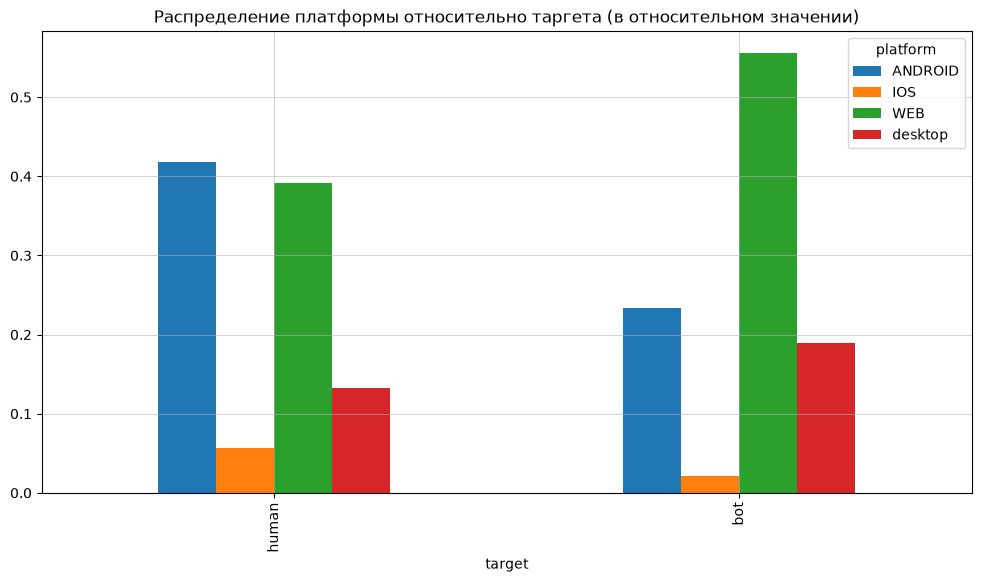

In [41]:
platform_target_cls_b.plot(kind='bar', figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Распределение платформы относительно таргета (в относительном значении)")
plt.show()

**Наблюдение:** боты в основном сидят на `WEB` платформе.

### Распределение событий <a id="events-dist"></a>
Посмотрим, какие события обычно соответствуют какому таргету.

In [42]:
events_cls_b = pd.crosstab(
    index=events_tr_labeled['target'], columns=events_tr_labeled['event_name'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})
events_cls_b

event_name,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
target,,,,,,,,,
human,0.019799,0.010289,0.036998,0.065824,0.365093,0.021480,0.122673,0.304771,0.053074
bot,0.014185,0.007922,0.025842,0.027163,0.436413,0.007809,0.070170,0.351530,0.058966


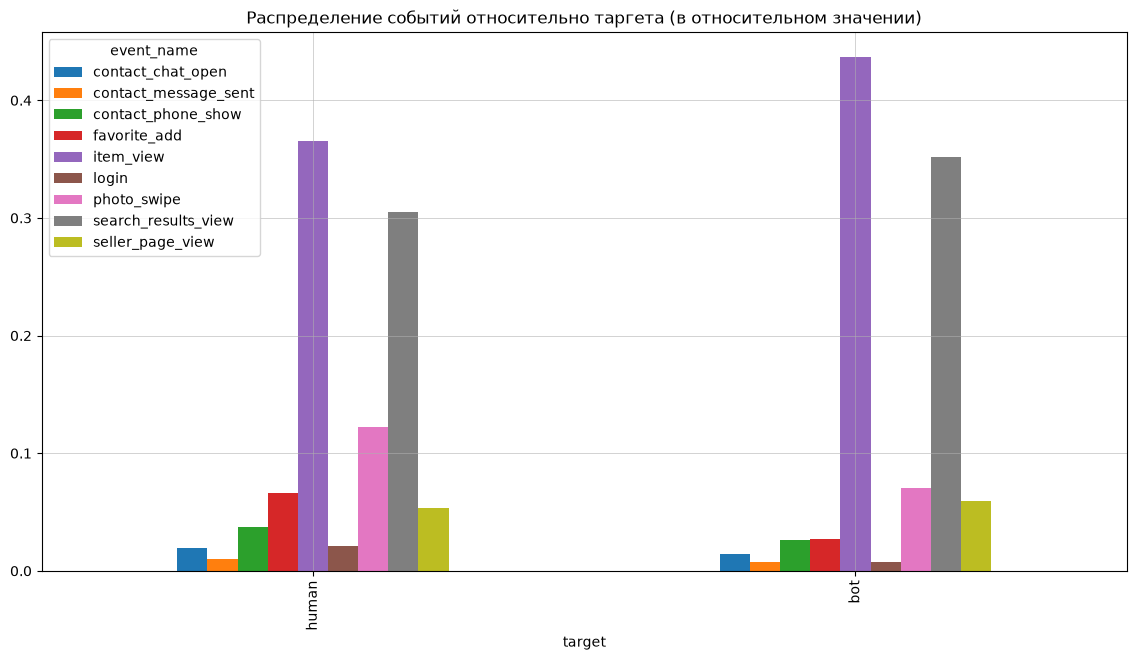

In [43]:
events_cls_b.plot(kind='bar', figsize=(14, 7))
plt.title("Распределение событий относительно таргета (в относительном значении)")
plt.grid(True, linewidth=0.4)
plt.show()

**Наблюдение:** распределения немного различаются -- у людей заметно чаще события: `login` (в ~3 раза), `favorite_add` (в ~2.5 раза), `photo_swipe` (в ~1.5 раза).

### Интенсивность событий <a id="intensity"></a>

Проверка среднего количество событий на куку -- хоть и дисбаланс классов присутствует, но боты могут интенсивнее генерировать запросы

In [44]:
events_per_cookie = events_tr_labeled.groupby(['cookie_id', 'target']).size().rename('n_events').reset_index() # чтобы оставить target, пришлось делать и по нему группировку
avg_events_per_cookie_cls_b = events_per_cookie.groupby('target')['n_events'].mean().rename(index={0:'human', 1:'bot'})
avg_events_per_cookie_cls_b

target
human    16.869015
bot      29.484983
Name: n_events, dtype: float64

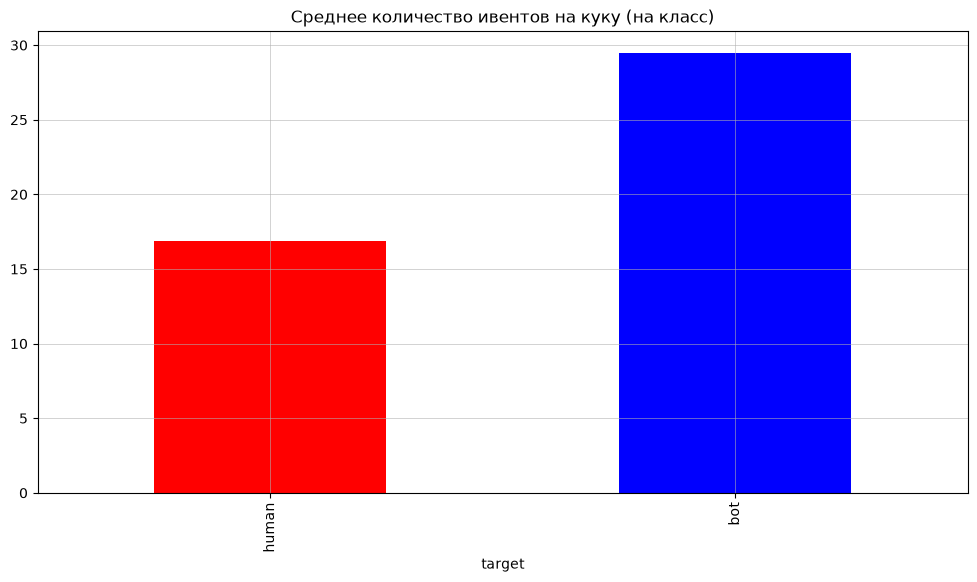

In [45]:
avg_events_per_cookie_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Среднее количество ивентов на куку (на класс)")
plt.show()

В перерасчете на куку, боты действительно генерируют больше событий (~в 2 раза больше)

# Feature engineering <a id="feature-engineering"></a>

In [46]:
def _build_meta_features(split: pd.DataFrame) -> pd.DataFrame:
    '''Фичи на основе одних лишь данных сплита (трейн/тест)
    '''
    return pd.DataFrame({
        'cookie_id': split['cookie_id'],
        'cookie_age_days': (split['window_start_ts'] - split['cookie_created_at']).dt.total_seconds() / (24 * 60 * 60), # боты почти сразу используют куку
        'hr_cookie_created_at': split['cookie_created_at'].dt.hour # пики активностей создания кук ботами
    })

def _build_event_time_features(event_split: pd.DataFrame) -> pd.DataFrame:
    '''lag-фичи для ивентов
    Сортирует события внутри куки (по времени) и добавляем lag
    '''
    ev = event_split.sort_values(['cookie_id', 'event_ts']).copy()
    g = ev.groupby('cookie_id')

    ev['gap_sec'] = g['event_ts'].diff().dt.total_seconds() # боты интенсивней (--> быстрее) шлют события
    ev['event_hr'] = ev['event_ts'].dt.hour

    return ev

def _build_event_intesity_features(feat: pd.DataFrame) -> pd.DataFrame:
    '''Интесивность активности внутри окна
    '''
    span = (feat['last_event_ts'] - feat['first_event_ts']).dt.total_seconds()
    return pd.DataFrame({
        'session_span_sec': span, # длительность активной сессии
        'gap_coeff_var': feat['std_gap_sec'] / feat['mean_gap_sec']
    })

def _build_event_name_shares(ev: pd.DataFrame) -> pd.DataFrame:
    '''Доля каждого события среди событий куки в окне
    '''
    return pd.crosstab(ev['cookie_id'], ev['event_name'], normalize='index').add_prefix('share_')

def _build_platform_shares(ev: pd.DataFrame) -> pd.DataFrame:
    '''Доля каждой платформы среди платформ куки в окне
    '''
    return pd.crosstab(ev['cookie_id'], ev['platform'], normalize='index').add_prefix('share_platform_')

def _build_night_share(ev: pd.DataFrame) -> pd.DataFrame:
    '''Доля событий по часам с 0 до 6
    Боты работают круглосуточно
    '''
    return ev.groupby('cookie_id')['evnet_hr'].apply(lambda x: (x < 6).mean()).rename('night_share')
    
def _build_pointer_missing_feature(ev: pd.DataFrame) -> pd.Series:
    '''Считает долю пропусков коорд курсора только для WEB/desktop
    '''
    mask = (ev['platform'].isin(['WEB', 'desktop']))
    return ev[mask].groupby('cookie_id')['pointer_x'].apply(lambda x: x.isna().mean())

def _build_event_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Различные агрегации из окна ивента для куки
    '''
    ev = _build_event_time_features(event_split)
    g = ev.groupby('cookie_id')

    f = g.agg(
        n_events=('cookie_id', 'size'),
        
        n_unique_items=('item_id', 'nunique'),
        n_unique_categories=('item_category', 'nunique'),
        n_unique_locations=('item_location', 'nunique'),
        n_unique_platforms=('platform', 'nunique'),

        n_unique_ua=('user_agent', 'nunique'),
        
        n_search_events=('search_query', 'count'),
        avg_search_page=('search_page', 'mean'),
        max_search_page=('search_page', 'max'),
        
        median_gap_sec=('gap_sec', 'median'),
        mean_gap_sec=('gap_sec', 'mean'),
        std_gap_sec=('gap_sec', 'std'),
        min_gap_sec=('gap_sec', 'min'),
        max_gap_sec=('gap_sec', 'max'),

        first_event_hr=('event_hr', 'min'),
        last_event_hr=('event_hr', 'max'),
        first_event_ts=('event_ts', 'first'),
        last_event_ts=('event_ts', 'last')
    )

    f = pd.concat([f, _build_event_intesity_features(f), _build_event_name_shares(ev)], axis=1)
    f = f.drop(columns=['first_event_ts', 'last_event_ts']) # иначе catboost ругается
    
    f['pointer_missing_rate'] = _build_pointer_missing_feature(ev)

    # Нормировка показателей (они в топе по важности)
    f['norm_n_unique_items'] = f['n_unique_items'] / f['n_events']
    f['norm_n_unique_categories'] = f['n_unique_categories'] / f['n_events']
    f['norm_n_unique_locations'] = f['n_unique_locations'] / f['n_events']

    return split[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')

def build_fe_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Объединяем построения признаков
    '''
    features_ev = _build_event_features(event_split, split)
    features_meta = _build_meta_features(split)

    return features_ev.merge(features_meta, on='cookie_id', how='left')

def _get_search_text(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.Series:
    '''Получает все search_query конкретной куки в ее окне (одной строкой)
    '''
    text = event_split.groupby('cookie_id')['search_query'].agg(
        lambda s: ' '.join(s.dropna())
    )
    return split['cookie_id'].map(text).fillna('')

def _get_user_agent(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.Series:
    '''Все уникальные user_agent конкретной куки в окне
    Порядок детерминирован через сортировку
    '''
    ua = event_split.groupby('cookie_id')['user_agent'].agg(
        lambda s: ' '.join(sorted(s.dropna().unique()))
    )
    return split['cookie_id'].map(ua).fillna('')

def build_text_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Строит текстовые признаки
    '''
    return pd.DataFrame({
        'cookie_id': split['cookie_id'],
        'search_text': _get_search_text(event_split, split),
        'user_agents': _get_user_agent(event_split, split)
    })

# Валидация <a id="validation"></a>

Наблюдения:
1. Необходимо соблюдать time-based сплит (из-за возможной утечки данных, в противном случае)
2. Из-за большого дисбаланса классов лучше построить сплит с расширяемым окном (иначе шумит оценка $P@R_{\ge{0.7}}$)

In [47]:
def build_time_blocks_cv(train: pd.DataFrame, n_splits: int) -> tuple[pd.Series, pd.Series]:
    '''Функция для построения валидации -- расширяемое окно на основе time-based сплита
    Проводит ленивое вычисление
    '''
    dates = np.sort(train['window_start_ts'].unique())
    blocks = np.array_split(dates, n_splits+1) #! у np.split мб ValueError из-за нецелого разбиения

    for i in range(1, n_splits + 1):
        val_mask = blocks[i]
        val_ts = train['window_start_ts'].isin(val_mask)
        train_ts = train['window_start_ts'].isin(np.concatenate(blocks[:i]))

        yield train_ts, val_ts   

In [48]:
from sklearn.metrics import auc
from metric import precision_at_recall, pr_curve

def build_train_loop(X_train: pd.DataFrame, y_train: pd.Series, cv_split: tuple[pd.Series, pd.Series], features: list[str], params: dict, verbose: bool = True) -> list[float]:
    '''Вынос логики обучения с cv в отдельную функцию
    Возвращает скоры модели по всем фолдам
    '''
    scores = []
    for idx, (train_ts, val_ts) in enumerate(cv_split):
        model = cb.CatBoostClassifier(**params)
        
        model.fit(X_train.loc[train_ts, features], y_train[train_ts])
        proba = model.predict_proba(X_train.loc[val_ts, features])[:, 1]
        
        score = precision_at_recall(y_train[val_ts], proba)
        scores.append(score)
        
        if verbose:
            p, r = pr_curve(y_train[val_ts], proba)
            pr_auc = auc(r, p)
            
            print('-'*10)
            print(f"SPLIT#{idx}")
            print(f"\tsize_tr={train_ts.sum()}, size_val={val_ts.sum()}")
            print(f"\tn_bots_tr={y_train[train_ts].sum()}, n_bots_val={y_train[val_ts].sum()}")
            print(f"score={score:.4f}, pr_auc={pr_auc:.4f}")

    return scores

# Бейзлайн <a id="baseline"></a>
`catboost` с самым маленьким набором фич.

In [49]:
def build_baseline_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Строит минимальный набор фич (для бейзлайна)
    '''
    event_split = event_split.groupby('cookie_id').agg(
        n_events = ('cookie_id', 'size'),
        n_unique_items = ('item_id', 'nunique')
    )
    return split[['cookie_id']].merge(event_split.reset_index(), on='cookie_id', how='left').fillna(0)

In [50]:
X_train_bl = build_baseline_features(events_tr, train)
X_test_bl = build_baseline_features(events_te, test)
y_train_bl = train['target'].values

features_bl = ['n_events', 'n_unique_items']
params_bl = {
    'random_state': SEED,
    'iterations': ITERATIONS,
    'verbose': False
}

X_train_bl.shape, y_train_bl.shape, X_test_bl.shape

((11091, 3), (11091,), (4909, 3))

In [51]:
scores_bl = build_train_loop(
    X_train_bl, y_train_bl, 
    build_time_blocks_cv(train, N_SPLITS),
    features_bl, params_bl
)

print('-'*10)
print(f"score.mean={np.mean(scores_bl):.4f}, score.std={np.std(scores_bl):.4f}")

----------
SPLIT#0
	size_tr=3305, size_val=3468
	n_bots_tr=263, n_bots_val=281
score=0.1086, pr_auc=0.2747
----------
SPLIT#1
	size_tr=6773, size_val=2367
	n_bots_tr=544, n_bots_val=195
score=0.1236, pr_auc=0.2551
----------
SPLIT#2
	size_tr=9140, size_val=1951
	n_bots_tr=739, n_bots_val=160
score=0.1146, pr_auc=0.1869
----------
score.mean=0.1156, score.std=0.0062


# Обучение <a id="training"></a>

## Основанное на поведенческих признаках <a id="training-fe"></a>
Без `text_features` у `catboost` по `search_query` и `user_agent`.

In [52]:
X_train_fe = build_fe_features(events_tr, train)
X_test_fe = build_fe_features(events_te, test)
y_train_fe = train['target'].values

features_fe = X_train_fe.columns.drop('cookie_id')
params_fe = {
    'random_state': SEED,
    'iterations': ITERATIONS,
    'verbose': False
}

X_train_fe.shape, y_train_fe.shape, X_test_fe.shape

((11091, 34), (11091,), (4909, 34))

In [53]:
scores_fe = build_train_loop(
    X_train_fe, y_train_fe, 
    build_time_blocks_cv(train, N_SPLITS),
    features_fe, params_fe
)

print('-'*10)
print(f"score.mean={np.mean(scores_fe):.4f}, score.std={np.std(scores_fe):.4f}")

----------
SPLIT#0
	size_tr=3305, size_val=3468
	n_bots_tr=263, n_bots_val=281
score=0.5427, pr_auc=0.6947
----------
SPLIT#1
	size_tr=6773, size_val=2367
	n_bots_tr=544, n_bots_val=195
score=0.5415, pr_auc=0.7112
----------
SPLIT#2
	size_tr=9140, size_val=1951
	n_bots_tr=739, n_bots_val=160
score=0.5229, pr_auc=0.6853
----------
score.mean=0.5357, score.std=0.0090


## Дополнение текстовыми признаками <a id="training-text"></a>
Дополним поведенческие признаки двумя другими -- `search_query` (`search_text`) и `user_agent` (`user_agents`).

In [54]:
X_train_txt = X_train_fe.merge(build_text_features(events_tr, train), on='cookie_id', how='left')
X_test_txt = X_test_fe.merge(build_text_features(events_te, test), on='cookie_id', how='left')
y_train_txt = train['target'].values

features_txt = X_train_txt.columns.drop('cookie_id')
params_txt = {
    'random_state': SEED,
    'iterations': ITERATIONS,
    'text_features': ['search_text', 'user_agents'],
    'verbose': False
}

X_train_txt.shape, y_train_txt.shape, X_test_txt.shape

((11091, 36), (11091,), (4909, 36))

In [55]:
scores_txt = build_train_loop(
    X_train_txt, y_train_txt,
    build_time_blocks_cv(train, N_SPLITS),
    features_txt, params_txt
)
print(f"score.mean={np.mean(scores_txt):.4f}, score.std={np.std(scores_txt):.4f}")

----------
SPLIT#0
	size_tr=3305, size_val=3468
	n_bots_tr=263, n_bots_val=281
score=0.5518, pr_auc=0.6803
----------
SPLIT#1
	size_tr=6773, size_val=2367
	n_bots_tr=544, n_bots_val=195
score=0.4790, pr_auc=0.6851
----------
SPLIT#2
	size_tr=9140, size_val=1951
	n_bots_tr=739, n_bots_val=160
score=0.5517, pr_auc=0.6845
score.mean=0.5275, score.std=0.0343


### Анализ признаков <a id="features-analysis"></a>

In [56]:
def fit_model(X_train: pd.DataFrame, y_train: pd.Series, params: dict) -> cb.CatBoostClassifier:
    '''Обертка -- обучение на всем сплите
    '''
    model = cb.CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    return model

In [57]:
model_fe = fit_model(X_train_fe[features_fe], y_train_fe, params_fe)
model_fe.get_feature_importance(prettified=True)

,Feature Id,Importances
0,median_gap_sec,12.171653
1,n_unique_categories,6.776920
2,norm_n_unique_items,5.637562
3,norm_n_unique_categories,5.077690
4,avg_search_page,4.617825
5,n_unique_locations,4.598433
6,cookie_age_days,4.473001
7,norm_n_unique_locations,3.863075
8,min_gap_sec,3.514164
9,share_favorite_add,3.330537


In [58]:
model_txt = fit_model(X_train_txt[features_txt], y_train_txt, params_txt)
model_txt.get_feature_importance(prettified=True)

,Feature Id,Importances
0,median_gap_sec,15.123330
1,n_unique_categories,10.850079
2,user_agents,6.761010
3,n_unique_locations,6.516683
4,search_text,6.479003
5,norm_n_unique_categories,5.507827
6,avg_search_page,4.565743
7,norm_n_unique_items,4.020764
8,norm_n_unique_locations,3.656370
9,share_contact_phone_show,3.520285


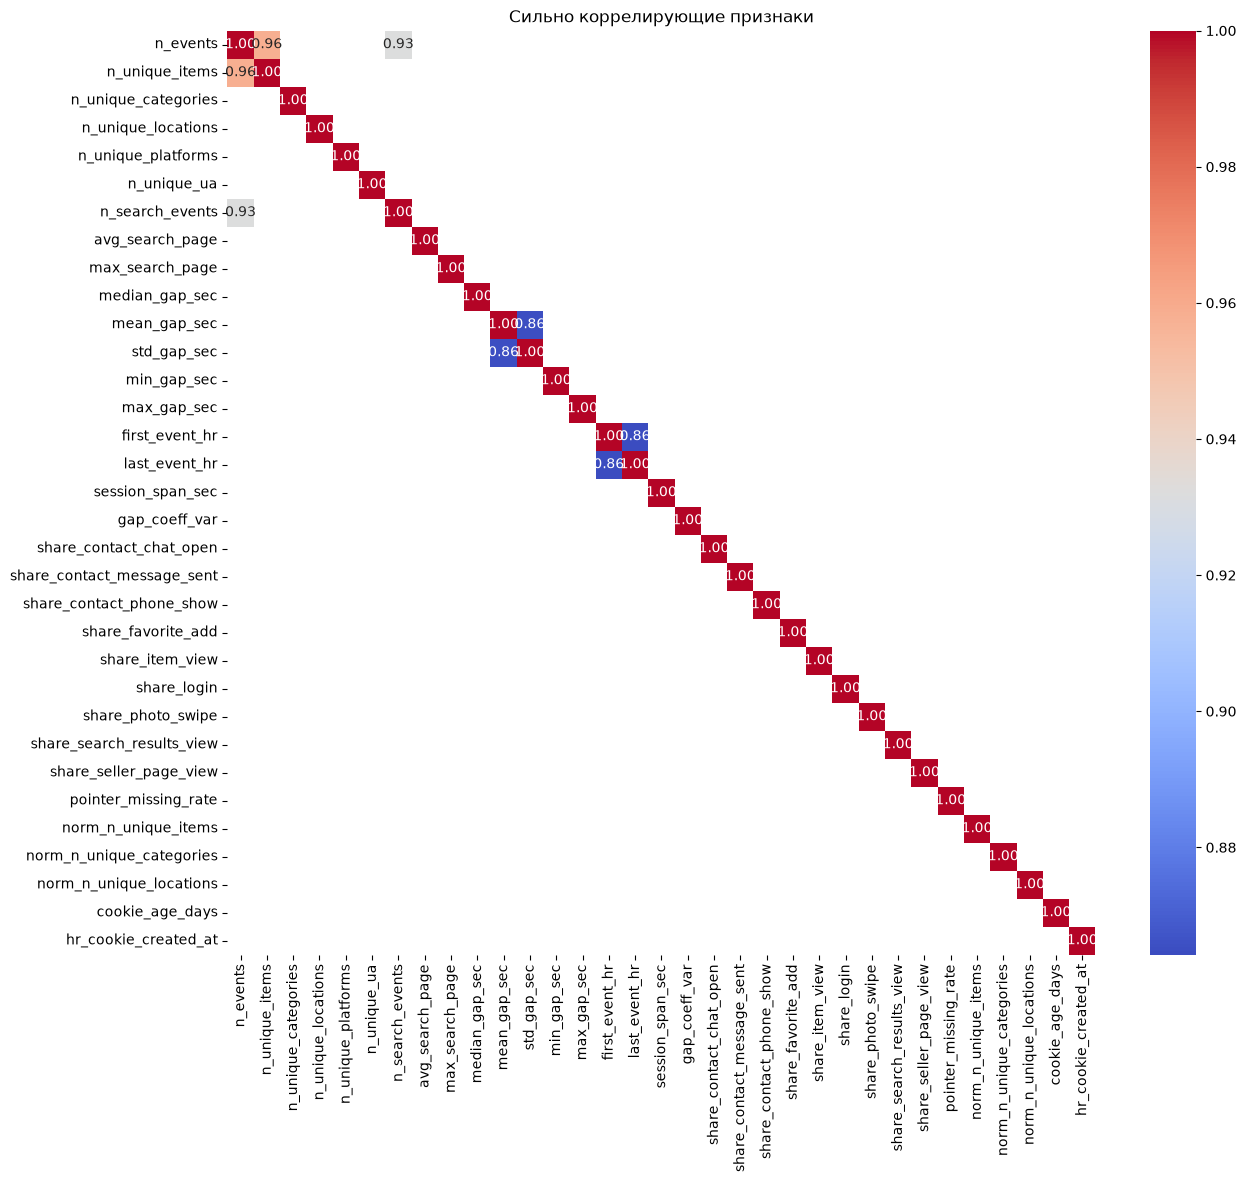

In [59]:
mat = X_train_fe.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    mat, mask=(mat.abs() <= 0.85),
    cmap='coolwarm', annot=True, fmt='.2f'
)
plt.title("Сильно коррелирующие признаки")
plt.show()

**Наблюдения:**
- `n_events` сильно связан с `n_unique_items` и `n_search_events`: больше событий --> больше уникальных объектов и поисков

# Подбор гиперпараметров <a id="tuning"></a>

In [60]:
from sklearn.model_selection import ParameterSampler

def tune_params(X_train, y_train, train, features, base_params, grid, n_iter=12) -> pd.DataFrame:
    '''Подбор гиперпараметров через RandomSearch
    '''
    rows = []
    for i, p in enumerate(ParameterSampler(grid, n_iter=n_iter, random_state=SEED)):
        params = {**base_params, **p}
        scores = build_train_loop(
            X_train, y_train,
            build_time_blocks_cv(train, N_SPLITS),
            features, params, verbose=False
        )
        rows.append({**p, 'mean': np.mean(scores), 'std': np.std(scores)})
        print(f"{i}: mean={np.mean(scores):.4f}, std={np.std(scores):.4f}")
        print(f"\t{p}")
    return pd.DataFrame(rows).sort_values('mean', ascending=False).reset_index(drop=True)

In [61]:
from scipy.stats import uniform
from scipy.stats import randint 

params_fe = {
    'random_state': SEED,
    'thread_count': -1,
    'verbose': False,
}

grid = {
    'depth': randint(5, 7),
    'iterations': randint(1500, 2500),
    'learning_rate': uniform(0.01, 0.03),
    'l2_leaf_reg': randint(30, 500),
    'auto_class_weights': ['SqrtBalanced', 'Balanced'],
}

res_fe = tune_params(X_train_fe, y_train_fe, train, features_fe, params_fe, grid, n_iter=10)
res_fe.head()

best_fe = res_fe.iloc[0][list(grid)].to_dict()
best_params_fe = {**params_fe, **best_fe}

print('-'*10)
print(f"best: {best_fe}")

0: mean=0.5423, std=0.0211
	{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 2360, 'l2_leaf_reg': 300, 'learning_rate': np.float64(0.03195981825434215)}
1: mean=0.5443, std=0.0386
	{'auto_class_weights': 'SqrtBalanced', 'depth': 5, 'iterations': 2114, 'l2_leaf_reg': 151, 'learning_rate': np.float64(0.01467983561008608)}
2: mean=0.5428, std=0.0274
	{'auto_class_weights': 'SqrtBalanced', 'depth': 5, 'iterations': 1587, 'l2_leaf_reg': 402, 'learning_rate': np.float64(0.028033450352296263)}
3: mean=0.5031, std=0.0485
	{'auto_class_weights': 'Balanced', 'depth': 5, 'iterations': 2161, 'l2_leaf_reg': 338, 'learning_rate': np.float64(0.03909729556485983)}
4: mean=0.5054, std=0.0275
	{'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 2305, 'l2_leaf_reg': 415, 'learning_rate': np.float64(0.015454749016213017)}
5: mean=0.5369, std=0.0402
	{'auto_class_weights': 'SqrtBalanced', 'depth': 5, 'iterations': 1959, 'l2_leaf_reg': 343, 'learning_rate': np.float64(0.025742692948

"\n0: mean=0.5696, std=0.0291\n\t{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 2360, 'l2_leaf_reg': 300, 'learning_rate': np.float64(0.03195981825434215)}\n"

In [62]:
params_txt = {
    'random_state': SEED,
    'thread_count': -1,
    'verbose': False,
    'text_features': ['search_text', 'user_agents'],
}

grid = {
    'depth': randint(6, 7), # базовая модель должна быть более сложной (из-за текстовых признаков)
    'iterations': randint(1000, 1500),
    'learning_rate': uniform(0.03, 0.03),
    'l2_leaf_reg': randint(1, 20),
    'auto_class_weights': ['SqrtBalanced', 'Balanced'],
}

res_txt = tune_params(X_train_txt, y_train_txt, train, features_txt, params_txt, grid, n_iter=10)
res_txt.head()

best_txt = res_txt.iloc[0][list(grid)].to_dict()
best_params_txt = {**params_txt, **best_txt}

print('-'*10)
print(f"best: {best_txt}")

0: mean=0.5286, std=0.0563
	{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 1435, 'l2_leaf_reg': 15, 'learning_rate': np.float64(0.05195981825434215)}
1: mean=0.5371, std=0.0684
	{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 1020, 'l2_leaf_reg': 7, 'learning_rate': np.float64(0.043374982585607735)}
2: mean=0.5395, std=0.0525
	{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 1330, 'l2_leaf_reg': 11, 'learning_rate': np.float64(0.055985284373248054)}
3: mean=0.5230, std=0.0427
	{'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 1359, 'l2_leaf_reg': 3, 'learning_rate': np.float64(0.030617534828874072)}
4: mean=0.5153, std=0.0724
	{'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 1343, 'l2_leaf_reg': 12, 'learning_rate': np.float64(0.058156581270472504)}
5: mean=0.5165, std=0.0428
	{'auto_class_weights': 'Balanced', 'depth': 6, 'iterations': 1191, 'l2_leaf_reg': 1, 'learning_rate': np.float64(0.03912726728878613)}
6: 

"\n1: mean=0.5230, std=0.0792\n\t{'auto_class_weights': 'SqrtBalanced', 'depth': 6, 'iterations': 1020, 'l2_leaf_reg': 7, 'learning_rate': np.float64(0.043374982585607735)}\n"

# Сабмит <a id="submission"></a>

In [63]:
def get_submit(model: cb.CatBoostClassifier, X_test: pd.DataFrame, features: list[str], filename: str) -> None:
    '''Обертка над финальным обучением и сабмитом
    '''
    sub = pd.DataFrame({
    'cookie_id': X_test['cookie_id'],
    'score': model.predict_proba(X_test[features])[:, 1],
    })

    assert len(sub) == len(test) and sub['score'].between(0, 1).all()

    sub.to_csv(filename, index=False)
    return sub.head()

In [64]:
get_submit(fit_model(X_train_fe[features_fe], y_train_fe, best_params_fe), X_test_fe, features_fe, 'submission-fe.csv')

,cookie_id,score
0,ck_315fb710a0e371e7,0.011720
1,ck_a76ee3b3e3e522fd,0.174497
2,ck_94c9a4d382689e82,0.076450
3,ck_8eaf9509ad9462a0,0.017298
4,ck_9a88a5a989cb5bc6,0.016409


In [65]:
get_submit(fit_model(X_train_txt[features_txt], y_train_txt, best_params_txt), X_test_txt, features_txt, 'submission-txt.csv')

,cookie_id,score
0,ck_315fb710a0e371e7,0.005571
1,ck_a76ee3b3e3e522fd,0.186374
2,ck_94c9a4d382689e82,0.048862
3,ck_8eaf9509ad9462a0,0.007771
4,ck_9a88a5a989cb5bc6,0.027345


# Вывод <a id="conclusion"></a>

**Результаты:**
| Модель | mean | std |
|---|---|---|
| Baseline (`n_events`, `n_unique_items`) | 0.1156 | 0.0062 |
| Поведенческие признаки (FE) | 0.5357 | 0.0090 |
| FE + текст (`search_query`, `user_agent`) | 0.5275 | 0.0343 |
| FE, подобранные гиперпараметры | 0.5443 | 0.0386 |
| FE + текст, подобранные гиперпараметры | 0.5529 | 0.0536 |

**Что получилось:**
- baseline на 2ух признаках почти не отличается от случайного ранжирования (доля ботов ~8%).  
- Самые важные признаки: `median_gap_sec`, `n_unique_categories` (и нормированное значение), `n_unique_locations` (и нормированное значение), `avg_search_page`. То есть боты в первую очередь отличаются темпом и "шириной" просмотров, а не составом событий.
- Текстовые признаки сильного прироста не дали: среднее ~то же, а разброс чуть выше.
- Подбор гиперпараметров дал +0.02-0.03 на валидации, но это меньше `std` по фолдам, так что улучшение нельзя считать надежным.

**Ограничения:**
- На фолд приходится мало ботов (~200), поэтому P@R сильно шумит.
- Событие `captcha_shown` встречается только после окна наблюдения, поэтому в признаки не попало.